# 03 · Boolean Algebra, Truth Tables & Karnaugh Maps
**Course:** SLAO · Chapter 3 *Les circuits logiques* + TD2 · ISG Tunis
**Covers:** logic gates, canonical forms (SOP), Karnaugh simplification, TD2 exercises 1, 2, 5, 6

---

## Objectives
1. Model gates as functions and build **truth tables** programmatically.
2. Prove Boolean identities by exhaustive enumeration (the "proof by truth table" of the course).
3. Write the **canonical sum of products** (SOP) from a truth table.
4. Simplify with **Karnaugh maps**, drawn with Gray-code ordering and colour-coded groups.
5. Cross-check every hand method with an automatic **Quine–McCluskey** minimiser, then draw the circuit.

## Workflow used for every logic problem

```
specification ─▶ truth table ─▶ canonical SOP ─▶ Karnaugh map ─▶ minimal SOP ─▶ logic circuit
                                                       └── verified by Quine–McCluskey + exhaustive equivalence
```

## Contents
1. Setup
2. Gates and truth tables
3. Boolean laws proved by enumeration
4. Canonical form (SOP)
5. Karnaugh map engine
6. Quine–McCluskey minimiser (automatic check)
7. The `solve()` pipeline
8. Examples from the course
9. TD2 solutions

## 1 · Setup

In [1]:
%matplotlib inline
from __future__ import annotations
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import Math, display
import schemdraw
from schemdraw.parsing import logicparse

schemdraw.use("matplotlib")
pd.set_option("display.width", 120)

## 2 · Gates and truth tables

A logic function of $n$ variables maps $\{0,1\}^n \to \{0,1\}$; there are only $2^n$ input cases, so a function
is **completely described by its truth table**. The row order below is binary counting, so the row number *is*
the **minterm index** (e.g. row 5 of three variables = `101`).

In [2]:
def AND(*x):  return int(all(x))
def OR(*x):   return int(any(x))
def NOT(a):   return 1 - a
def NAND(*x): return NOT(AND(*x))
def NOR(*x):  return NOT(OR(*x))
def XOR(*x):  return sum(x) % 2          # 1 iff the number of 1-inputs is odd (course definition)
def XNOR(*x): return NOT(XOR(*x))


def truth_table(f, names) -> pd.DataFrame:
    rows = [(*bits, int(f(*bits))) for bits in itertools.product((0, 1), repeat=len(names))]
    return pd.DataFrame(rows, columns=[*names, "out"])


def ones_of(f, n: int) -> list[int]:
    """Minterm indices where f = 1."""
    return [i for i, bits in enumerate(itertools.product((0, 1), repeat=n)) if f(*bits)]


gates = pd.DataFrame(
    [(a, b, AND(a, b), OR(a, b), NAND(a, b), NOR(a, b), XOR(a, b), XNOR(a, b))
     for a, b in itertools.product((0, 1), repeat=2)],
    columns=["a", "b", "AND", "OR", "NAND", "NOR", "XOR", "XNOR"])
gates

,a,b,AND,OR,NAND,NOR,XOR,XNOR
0,0,0,0,0,1,1,0,1
1,0,1,0,1,1,0,1,0
2,1,0,0,1,1,0,1,0
3,1,1,1,1,0,0,0,1


**NAND and NOR are universal**: any function can be built from NAND gates alone. Verified exhaustively:

In [3]:
not_ = lambda a:    NAND(a, a)
and_ = lambda a, b: NAND(NAND(a, b), NAND(a, b))
or_  = lambda a, b: NAND(NAND(a, a), NAND(b, b))

assert all(not_(a) == NOT(a) for a in (0, 1))
assert all(and_(a, b) == AND(a, b) and or_(a, b) == OR(a, b) for a, b in itertools.product((0, 1), repeat=2))
print("NOT, AND and OR rebuilt from NAND only: verified on every input combination.")

NOT, AND and OR rebuilt from NAND only: verified on every input combination.


## 3 · Boolean laws proved by enumeration

*Proof by truth table*: two functions are equal iff their tables are equal. `equivalent(f, g, n)` tests all
$2^n$ cases, so a passing assertion is a **complete proof**, not a sample test.

In [4]:
def equivalent(f, g, n: int) -> bool:
    return all(f(*bits) == g(*bits) for bits in itertools.product((0, 1), repeat=n))


laws = {
    "De Morgan 1   not(a.b) = not(a) + not(b)":  (lambda a, b: NOT(AND(a, b)), lambda a, b: OR(NOT(a), NOT(b)), 2),
    "De Morgan 2   not(a+b) = not(a) . not(b)":  (lambda a, b: NOT(OR(a, b)),  lambda a, b: AND(NOT(a), NOT(b)), 2),
    "Absorption 1  a + a.b = a":                 (lambda a, b: OR(a, AND(a, b)), lambda a, b: a, 2),
    "Absorption 2  a.(a+b) = a":                 (lambda a, b: AND(a, OR(a, b)), lambda a, b: a, 2),
    "Distributive  a + b.c = (a+b).(a+c)":       (lambda a, b, c: OR(a, AND(b, c)), lambda a, b, c: AND(OR(a, b), OR(a, c)), 3),
    "Redundancy    a + not(a).b = a + b":        (lambda a, b: OR(a, AND(NOT(a), b)), lambda a, b: OR(a, b), 2),
    "XOR expansion a xor b = a.not(b) + not(a).b": (lambda a, b: XOR(a, b), lambda a, b: OR(AND(a, NOT(b)), AND(NOT(a), b)), 2),
    "Consensus     ab + not(a)c + bc = ab + not(a)c": (
        lambda a, b, c: OR(AND(a, b), AND(NOT(a), c), AND(b, c)),
        lambda a, b, c: OR(AND(a, b), AND(NOT(a), c)), 3),
}
pd.DataFrame({"law": list(laws), "proved": [equivalent(f, g, n) for f, g, n in laws.values()]})

,law,proved
0,De Morgan 1 not(a.b) = not(a) + not(b),True
1,De Morgan 2 not(a+b) = not(a) . not(b),True
2,Absorption 1 a + a.b = a,True
3,Absorption 2 a.(a+b) = a,True
4,Distributive a + b.c = (a+b).(a+c),True
5,Redundancy a + not(a).b = a + b,True
6,XOR expansion a xor b = a.not(b) + not(a).b,True
7,Consensus ab + not(a)c + bc = ab + not(a)c,True


## 4 · Canonical form: sum of products (SOP)

Take every row where $F = 1$ and write the product of **all** variables (a *minterm*): a variable is written as
itself if its value is 1, **inverted if it is 0**. The function is the sum (OR) of those minterms:

$$F = \sum m(\dots)$$

In [5]:
def bits_of(m: int, n: int) -> str:
    return format(m, f"0{n}b")


def canonical_sop(ones, names) -> str:
    n = len(names)
    return " + ".join("·".join(nm if b == "1" else f"¬{nm}" for nm, b in zip(names, bits_of(m, n))) for m in ones)


# Course example: F(A,B,C) is 1 for rows P3, P5, P6, P7
ones = [3, 5, 6, 7]
print("F =", canonical_sop(ones, "ABC"))
display(Math(r"F(A,B,C)=\sum m" + str(tuple(ones))))

F = ¬A·B·C + A·¬B·C + A·B·¬C + A·B·C


<IPython.core.display.Math object>

## 5 · Karnaugh map engine

A Karnaugh map is a truth table folded so that **neighbouring cells differ by exactly one variable**
(rows and columns follow the **Gray code** `00, 01, 11, 10`). Grouping neighbouring 1s removes the variable that changes.

**Grouping rules (from the course)**
* groups contain $2^k$ cells (1, 2, 4, 8…), forming a line, column or rectangle – **never a diagonal**;
* the map **wraps around** (left edge touches right edge, top touches bottom);
* every 1 must be covered, and groups should be **as large as possible**;
* a group of 2 cells eliminates 1 variable; a group of 4 eliminates 2.

**Reading a group:** AND the variables that *do not change*; write a variable inverted if it is 0 in the group.
The function is the OR of all the group terms.

Layout conventions follow the course: 2 variables → `A` columns / `B` rows; 3 variables → `AB` columns / `C` rows;
4 variables → `AB` rows / `CD` columns.

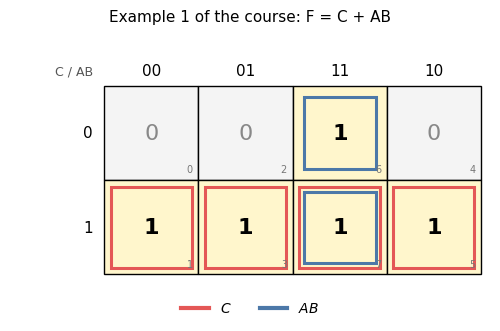

In [6]:
LAYOUT = {2: ([1], [0]), 3: ([2], [0, 1]), 4: ([0, 1], [2, 3])}       # (row variables, column variables)
GRAY = {1: ["0", "1"], 2: ["00", "01", "11", "10"]}
COLOURS = ["#e45756", "#4c78a8", "#54a24b", "#f58518", "#b279a2", "#9d755d"]


def kmap_grid(n: int):
    rv, cv = LAYOUT[n]
    rows, cols = GRAY[len(rv)], GRAY[len(cv)]
    grid = []
    for r in rows:
        line = []
        for c in cols:
            bits = ["?"] * n
            for v, b in zip(rv, r): bits[v] = b
            for v, b in zip(cv, c): bits[v] = b
            line.append(int("".join(bits), 2))
        grid.append(line)
    return rows, cols, grid


def matches(imp: str, m: int, n: int) -> bool:
    """Does minterm m belong to the implicant (a string over 0/1/-)?"""
    return all(i == "-" or i == b for i, b in zip(imp, bits_of(m, n)))


def latex_term(imp: str, names) -> str:
    parts = [nm if ch == "1" else r"\overline{" + nm + "}" for ch, nm in zip(imp, names) if ch != "-"]
    return "".join(parts) or "1"


def latex_sop(cover, names) -> str:
    return " + ".join(latex_term(i, names) for i in cover) if cover else "0"


def plot_kmap(ones, n: int, names, cover=(), title: str = "", dontcares=()):
    rows, cols, grid = kmap_grid(n)
    rv, cv = LAYOUT[n]
    H, W = len(rows), len(cols)
    fig, ax = plt.subplots(figsize=(1.0 * W + 2.2, 0.85 * H + 1.9))
    for ri, line in enumerate(grid):
        for ci, m in enumerate(line):
            val = "1" if m in ones else ("X" if m in dontcares else "0")
            y = H - 1 - ri
            ax.add_patch(Rectangle((ci, y), 1, 1, fc="#fff6cc" if val != "0" else "#f4f4f4", ec="black", lw=1))
            ax.text(ci + .5, y + .5, val, ha="center", va="center", fontsize=16,
                    fontweight="bold" if val == "1" else "normal", color="#888" if val == "0" else "black")
            ax.text(ci + .94, y + .06, str(m), ha="right", va="bottom", fontsize=7, color="#777")
    for gi, imp in enumerate(cover):                        # one coloured frame per group, per covered cell
        inset = 0.07 + 0.05 * gi
        for ri, line in enumerate(grid):
            for ci, m in enumerate(line):
                if matches(imp, m, n):
                    ax.add_patch(Rectangle((ci + inset, H - 1 - ri + inset), 1 - 2 * inset, 1 - 2 * inset,
                                           fill=False, ec=COLOURS[gi % len(COLOURS)], lw=2.2))
    for ci, c in enumerate(cols): ax.text(ci + .5, H + .12, c, ha="center", fontsize=11)
    for ri, r in enumerate(rows): ax.text(-.12, H - 1 - ri + .5, r, ha="right", va="center", fontsize=11)
    ax.text(-.12, H + .12, "".join(names[v] for v in rv) + " / " + "".join(names[v] for v in cv),
            ha="right", fontsize=9, color="#555")
    if cover:
        handles = [Line2D([0], [0], color=COLOURS[i % len(COLOURS)], lw=3, label="$" + latex_term(imp, names) + "$")
                   for i, imp in enumerate(cover)]
        ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=len(handles), frameon=False)
    ax.set_xlim(-1.0, W + .1); ax.set_ylim(-.1, H + .6); ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)
    plt.show()


plot_kmap([1, 3, 5, 6, 7], 3, "ABC", cover=["--1", "11-"], title="Example 1 of the course: F = C + AB")

## 6 · Quine–McCluskey minimiser (automatic check)

Karnaugh maps are a *visual* method that works up to 4–6 variables. To make sure a hand-grouping is really
minimal, the notebook also runs the **Quine–McCluskey** algorithm, which is the algorithmic version of the same idea:

1. Repeatedly merge two terms that differ in exactly one bit (`0110` + `0111` → `011-`). Terms that can no longer
   be merged are the **prime implicants** (= the largest possible groups).
2. Choose the cheapest set of prime implicants that covers every 1: **essential** ones first
   (a 1 covered by a single group), then the cheapest completion.

Cost = (number of terms, number of literals). All equally cheap solutions are returned, because a Karnaugh map
can have several minimal answers.

In [7]:
def prime_implicants(ones, n: int, dontcares=()) -> list[str]:
    terms = {bits_of(m, n) for m in set(ones) | set(dontcares)}
    primes: set[str] = set()
    while terms:
        merged, used = set(), set()
        ordered = sorted(terms)
        for i, a in enumerate(ordered):
            for b in ordered[i + 1:]:
                diff = [k for k in range(n) if a[k] != b[k]]
                if len(diff) == 1 and "-" not in (a[diff[0]], b[diff[0]]):
                    merged.add(a[:diff[0]] + "-" + a[diff[0] + 1:])
                    used |= {a, b}
        primes |= terms - used
        terms = merged
    return sorted(primes)


def literals(imp: str) -> int:
    return sum(ch != "-" for ch in imp)


def minimal_covers(ones, primes, n: int) -> list[tuple[str, ...]]:
    ones = list(ones)
    best, best_cost = [], None
    for k in range(1, len(primes) + 1):
        for subset in itertools.combinations(primes, k):
            if all(any(matches(p, m, n) for p in subset) for m in ones):
                cost = (k, sum(literals(p) for p in subset))
                if best_cost is None or cost < best_cost:
                    best, best_cost = [subset], cost
                elif cost == best_cost:
                    best.append(subset)
        if best:                           # fewer terms always wins -> no need to try bigger sets
            break
    return best


def essential(ones, primes, n: int) -> list[str]:
    ess = set()
    for m in ones:
        owners = [p for p in primes if matches(p, m, n)]
        if len(owners) == 1:
            ess.add(owners[0])
    return sorted(ess)


def logic_expr(cover, names) -> str:
    """Expression string understood by schemdraw's logic parser."""
    terms = []
    for imp in cover:
        lits = [nm if ch == "1" else f"(not {nm})" for ch, nm in zip(imp, names) if ch != "-"]
        if not lits:
            return "1"
        terms.append("(" + " and ".join(lits) + ")" if len(lits) > 1 else lits[0])
    return " or ".join(terms) if terms else "0"


def draw_circuit(expr: str, label: str = "F") -> None:
    if expr in ("0", "1"):
        print(f"{label} is the constant {expr}: no gate needed (wire tied to {expr}).")
        return
    fig = logicparse(expr, outlabel=f"${label}$").draw(show=False).fig
    display(fig)
    plt.close(fig)

## 7 · The `solve()` pipeline

One call = truth table → canonical form → Karnaugh map with groups → minimal expression →
**exhaustive equivalence check** → circuit.

<IPython.core.display.Math object>

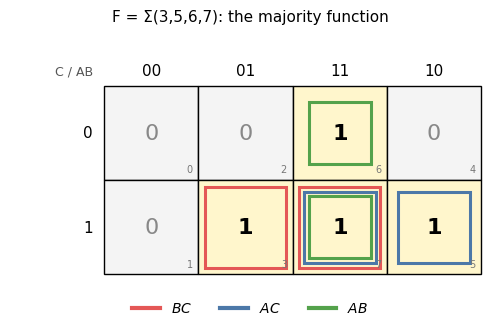

prime implicants : 3    essential : 3    minimal solutions : 1    cost : 3 term(s), 6 literal(s)


<IPython.core.display.Math object>

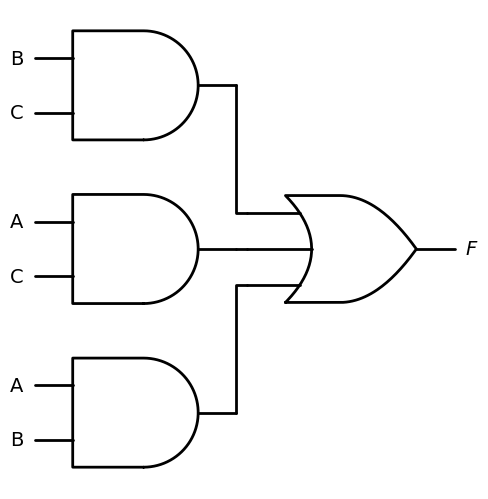

In [8]:
def solve(ones, n: int, names, label: str = "F", dontcares=(), circuit: bool = True, title: str = ""):
    ones = sorted(ones)
    display(Math(label + r"=\sum m" + str(tuple(ones)) + (r"\;+\;d" + str(tuple(sorted(dontcares))) if dontcares else "")))

    primes = prime_implicants(ones, n, dontcares)
    covers = minimal_covers(ones, primes, n)
    cover = covers[0]

    # Independent proof: the minimal SOP must be 1 exactly on `ones` (and may use don't-cares)
    realised = {m for m in range(2 ** n) if any(matches(p, m, n) for p in cover)}
    assert set(ones) <= realised <= set(ones) | set(dontcares), "minimisation changed the function!"

    plot_kmap(ones, n, names, cover=cover, dontcares=dontcares, title=title)
    print(f"prime implicants : {len(primes)}    essential : {len(essential(ones, primes, n))}    "
          f"minimal solutions : {len(covers)}    cost : {len(cover)} term(s), {sum(map(literals, cover))} literal(s)")
    display(Math(label + "=" + latex_sop(cover, names)))
    if len(covers) > 1:
        print("Equally minimal alternatives:")
        for alt in covers[1:]:
            display(Math(label + "=" + latex_sop(alt, names)))
    if circuit:
        draw_circuit(logic_expr(cover, names), label)
    return cover


cover = solve([3, 5, 6, 7], 3, "ABC", "F", title="F = Σ(3,5,6,7): the majority function")

## 8 · Examples from the course

### 8.1 · 3 variables

<IPython.core.display.Math object>

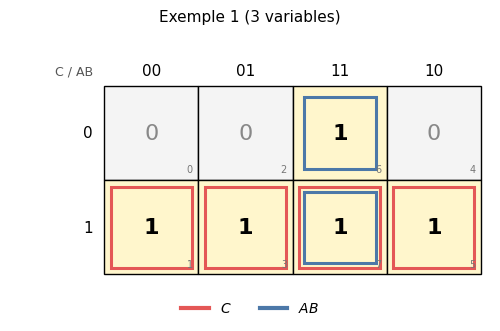

prime implicants : 2    essential : 2    minimal solutions : 1    cost : 2 term(s), 3 literal(s)


<IPython.core.display.Math object>

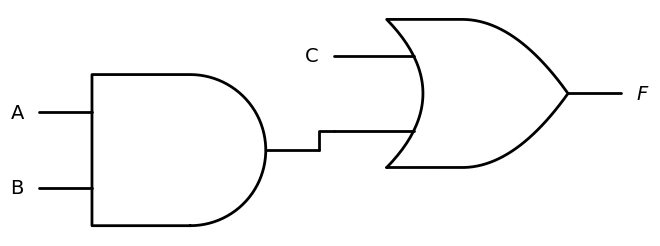

('--1', '11-')

In [9]:
# Slide 'Exemple 1': ones where C = 1, plus AB = 11, C = 0
solve([1, 3, 5, 6, 7], 3, "ABC", "F", title="Exemple 1 (3 variables)")

### 8.2 · 4 variables, three separate groups

<IPython.core.display.Math object>

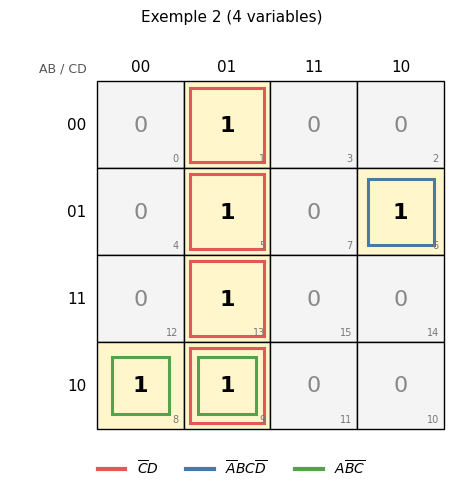

prime implicants : 3    essential : 3    minimal solutions : 1    cost : 3 term(s), 9 literal(s)


<IPython.core.display.Math object>

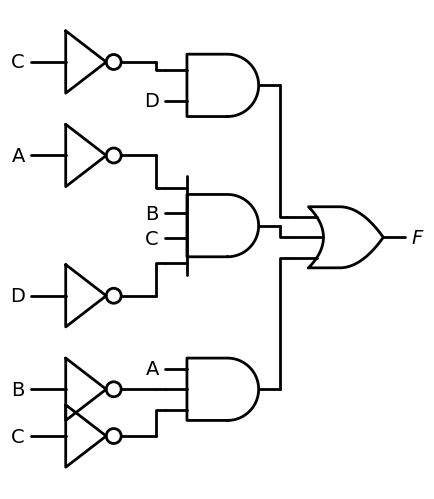

In [10]:
# Slide 'Exemple 2': groups  not(C).D   |   A.not(B).not(C)   |   not(A).B.C.not(D)
ones_ex2 = [1, 5, 9, 13, 8, 6]
cover = solve(ones_ex2, 4, "ABCD", "F", title="Exemple 2 (4 variables)")
assert set(cover) == {"--01", "100-", "0110"}

### 8.3 · 4 variables with wrap-around groups (corners and edges)

<IPython.core.display.Math object>

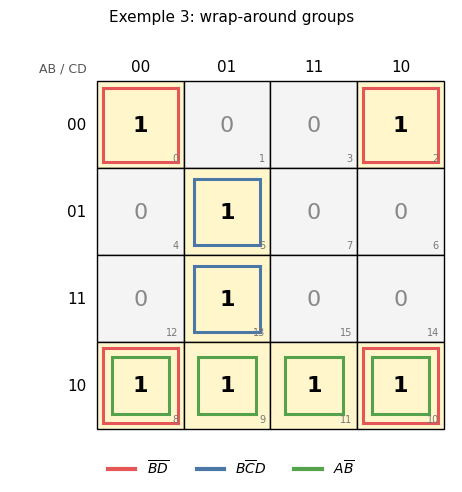

prime implicants : 4    essential : 3    minimal solutions : 1    cost : 3 term(s), 7 literal(s)


<IPython.core.display.Math object>

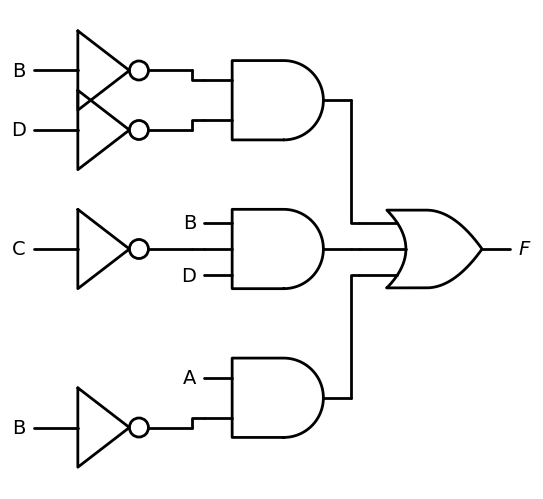

In [11]:
# Slide 'Exemple 3'. The groups wrap around the map: the four corner cells form ONE group of 4.
cover = solve([0, 2, 5, 8, 9, 10, 11, 13], 4, "ABCD", "F", title="Exemple 3: wrap-around groups")
assert set(cover) == {"10--", "-0-0", "-101"}          # A.not(B) + not(B).not(D) + B.not(C).D

### 8.4 · The two exercises left open in the slides

<IPython.core.display.Math object>

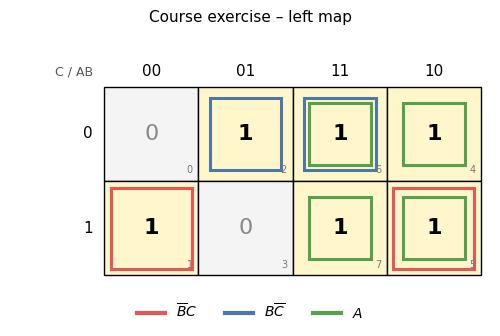

prime implicants : 3    essential : 3    minimal solutions : 1    cost : 3 term(s), 5 literal(s)


<IPython.core.display.Math object>

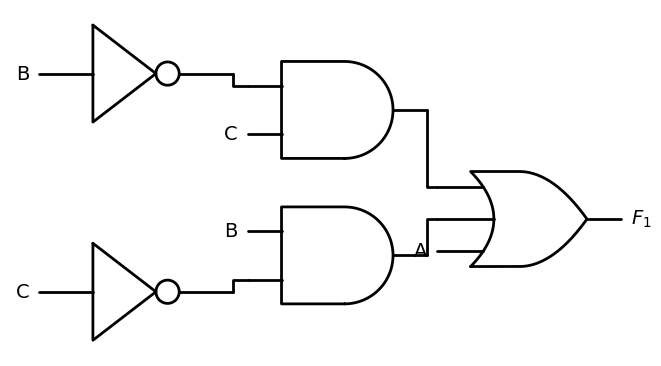

In [12]:
# Left map (3 variables, AB columns / C rows):   ones at A B C = 010, 110, 100, 001, 111, 101
cover_left = solve([1, 2, 4, 5, 6, 7], 3, "ABC", "F_1", title="Course exercise – left map")

<IPython.core.display.Math object>

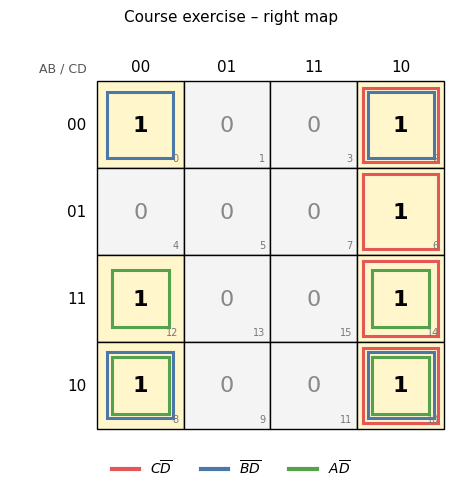

prime implicants : 3    essential : 3    minimal solutions : 1    cost : 3 term(s), 6 literal(s)


<IPython.core.display.Math object>

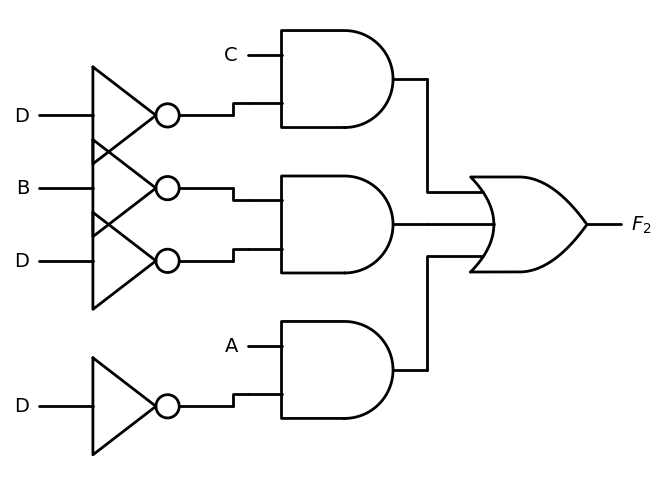

In [13]:
# Right map (4 variables):  CD = 00 -> AB in {00, 11, 10} ; CD = 10 -> all four AB
cover_right = solve([0, 2, 6, 8, 10, 12, 14], 4, "ABCD", "F_2", title="Course exercise – right map")

## 9 · TD2 solutions

### Exercise 1 – draw the circuits of two expressions

$$f_1(x,y,z)=\overline{(\bar x+\bar z)(x+y)}+(x+\bar z+y)\qquad\qquad f_2(x,y,z)=(x\oplus\bar y)+z$$

(For $f_1$ the overline is read as covering the whole product, as typeset in the handout.)

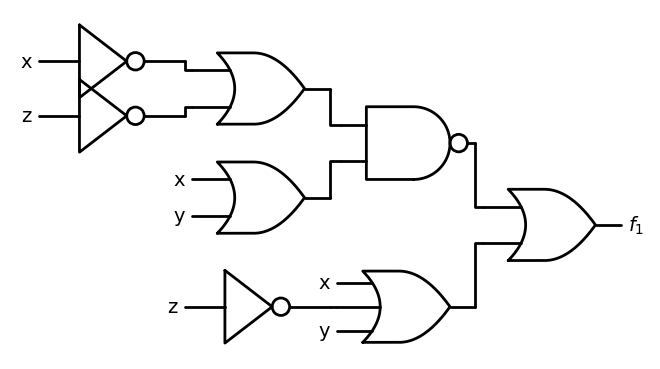

In [14]:
f1 = lambda x, y, z: OR(NOT(AND(OR(NOT(x), NOT(z)), OR(x, y))), OR(x, NOT(z), y))
f2 = lambda x, y, z: OR(XOR(x, NOT(y)), z)

draw_circuit("not (((not x) or (not z)) and (x or y)) or (x or (not z) or y)", "f_1")

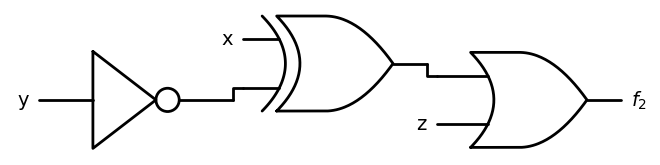

In [15]:
draw_circuit("(x xor (not y)) or z", "f_2")

**Simplification.** Let $P=(\bar x+\bar z)(x+y)$. When $P=1$, the factor $(x+y)$ is 1, so the second group
$(x+\bar z+y)$ is 1 as well; when $P=0$, $\overline P=1$. Either way $f_1=1$: it is a **tautology**, and the whole
circuit reduces to a constant. The enumeration confirms it, and shows how $f_2$ simplifies:

f1 = 1 for all 8 input combinations -> tautology.


<IPython.core.display.Math object>

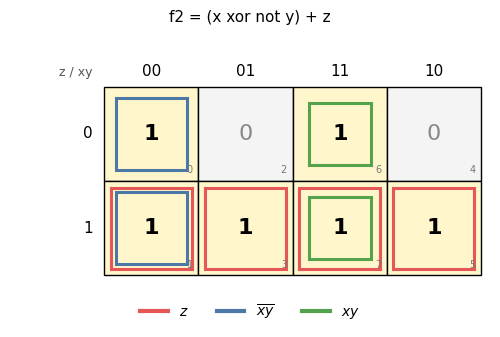

prime implicants : 3    essential : 3    minimal solutions : 1    cost : 3 term(s), 5 literal(s)


<IPython.core.display.Math object>

In [16]:
assert ones_of(f1, 3) == list(range(8)), "f1 should be 1 on all 8 rows"
print("f1 = 1 for all 8 input combinations -> tautology.")

cover_f2 = solve(ones_of(f2, 3), 3, "xyz", "f_2", circuit=False, title="f2 = (x xor not y) + z")
# x xor not(y) = XNOR(x, y) = x.y + not(x).not(y)   =>   f2 = x.y + not(x).not(y) + z
assert equivalent(f2, lambda x, y, z: OR(AND(x, y), AND(NOT(x), NOT(y)), z), 3)

> **If the overline covered only the first factor** (i.e. $\overline{\bar x+\bar z}\,(x+y)=xz(x+y)$), the function would
> not be a tautology; it would simplify to $x+y+\bar z$. The method above gives the answer for either reading.

### Exercise 2 – airline recruitment

Variables: `a` = Tunisian, `b` = single, `c` = male, `d` = under 25. A candidate is accepted if **at least one** criterion holds.
Each criterion is a product term with *don't-care* positions (`-` = the variable is irrelevant for that criterion):

| Criterion | a | b | c | d |
|---|:-:|:-:|:-:|:-:|
| single, male, Tunisian | 1 | 1 | 1 | – |
| single, Tunisian, under 25 | 1 | 1 | – | 1 |
| single woman, foreign | 0 | 1 | 0 | – |
| man under 25 | – | – | 1 | 1 |
| single and 25 or over | – | 1 | – | 0 |

**1) Truth table.** Z = 1 if any criterion matches.

In [17]:
criteria = ["111-", "11-1", "010-", "--11", "-1-0"]
names = "abcd"

ones_Z = [m for m in range(16) if any(matches(c, m, 4) for c in criteria)]
tt = pd.DataFrame([(*map(int, bits_of(m, 4)), int(m in ones_Z)) for m in range(16)], columns=[*names, "Z"])

# Compare with the published correction table (Z column, rows 0000 .. 1111)
correction_Z = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1]
assert tt.Z.tolist() == correction_Z
print("Truth table matches the correction.")
tt.T

Truth table matches the correction.


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
a,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
b,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1
c,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1
d,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
Z,0,0,0,1,1,1,1,1,0,0,0,1,1,1,1,1


**2) Canonical function**

In [18]:
print("Z =", canonical_sop(ones_Z, names))
display(Math(r"Z=\sum m" + str(tuple(ones_Z))))

Z = ¬a·¬b·c·d + ¬a·b·¬c·¬d + ¬a·b·¬c·d + ¬a·b·c·¬d + ¬a·b·c·d + a·¬b·c·d + a·b·¬c·¬d + a·b·¬c·d + a·b·c·¬d + a·b·c·d


<IPython.core.display.Math object>

**3) Karnaugh simplification and circuit**

<IPython.core.display.Math object>

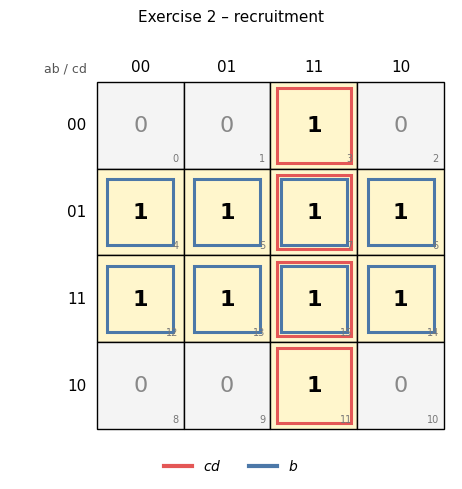

prime implicants : 2    essential : 2    minimal solutions : 1    cost : 2 term(s), 3 literal(s)


<IPython.core.display.Math object>

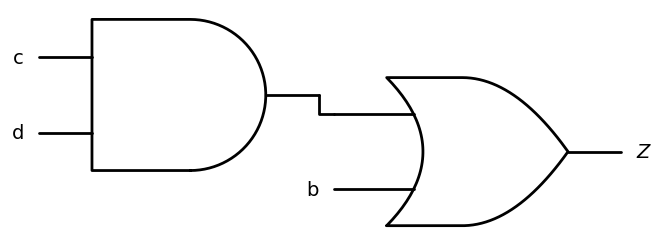

In [19]:
cover_Z = solve(ones_Z, 4, names, "Z", title="Exercise 2 – recruitment")
assert set(cover_Z) == {"-1--", "--11"}          # Z = b + c.d

**Reading.** $Z = b + c\cdot d$: *accept anyone who is single, or any man under 25.* Five criteria collapse into
one OR gate and one AND gate.

**4) With a 4→16 decoder** (done in notebook 04): $Z = S_3+S_4+\dots+S_7+S_{11}+\dots+S_{15}$, i.e. the OR of the
decoder outputs whose index is in $\{3,4,5,6,7,11,12,13,14,15\}$:

In [20]:
print("Decoder outputs to OR together:", ones_Z)

Decoder outputs to OR together: [3, 4, 5, 6, 7, 11, 12, 13, 14, 15]


### Exercise 5 – car warning system

`a` = seat belts fastened, `b` = engine running, `c` = driver door **closed**. The buzzer sounds (V = 1) if
(belts not fastened **and** engine running) **or** (engine running **and** door open).

,0,1,2,3,4,5,6,7
a,0,0,0,0,1,1,1,1
b,0,0,1,1,0,0,1,1
c,0,1,0,1,0,1,0,1
out,0,0,1,1,0,0,1,0


<IPython.core.display.Math object>

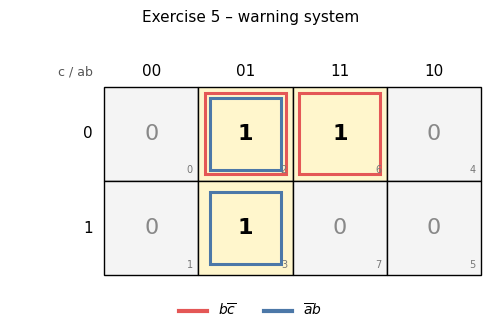

prime implicants : 2    essential : 2    minimal solutions : 1    cost : 2 term(s), 4 literal(s)


<IPython.core.display.Math object>

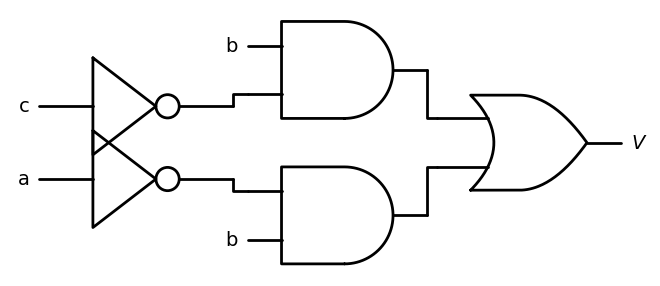

In [21]:
V = lambda a, b, c: OR(AND(NOT(a), b), AND(b, NOT(c)))
display(truth_table(V, "abc").T)
cover_V = solve(ones_of(V, 3), 3, "abc", "V", title="Exercise 5 – warning system")

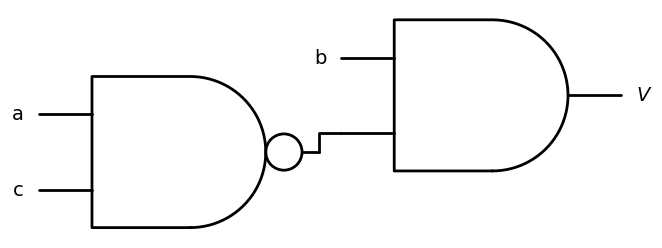

In [22]:
# Factorised form: V = b.(not(a) + not(c)) = b . NAND(a, c)  ->  one fewer gate
assert equivalent(V, lambda a, b, c: AND(b, NAND(a, c)), 3)
draw_circuit("b and (not (a and c))", "V")

**Reading.** $V=\bar a\,b+b\,\bar c = b\cdot\overline{a\,c}$: *the buzzer sounds whenever the engine runs and it is **not** the case that
(belts fastened and door closed).*

### Exercise 6 – simplify a function given by its truth table

In [23]:
table_F = [0, 1, 1, 0, 1, 1, 1, 0]                           # F(A,B,C) for rows 000 .. 111
ones_F = [m for m, v in enumerate(table_F) if v]
display(pd.DataFrame([(*map(int, bits_of(m, 3)), v) for m, v in enumerate(table_F)], columns=list("ABC") + ["F"]).T)
print("1) F =", canonical_sop(ones_F, "ABC"))

,0,1,2,3,4,5,6,7
A,0,0,0,0,1,1,1,1
B,0,0,1,1,0,0,1,1
C,0,1,0,1,0,1,0,1
F,0,1,1,0,1,1,1,0


1) F = ¬A·¬B·C + ¬A·B·¬C + A·¬B·¬C + A·¬B·C + A·B·¬C


<IPython.core.display.Math object>

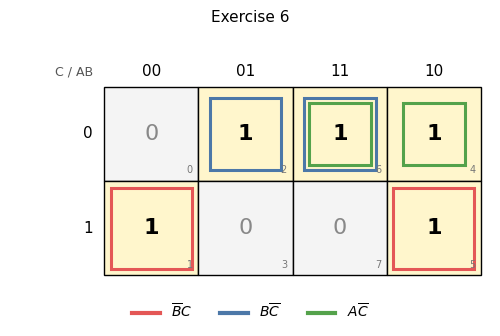

prime implicants : 4    essential : 2    minimal solutions : 2    cost : 3 term(s), 6 literal(s)


<IPython.core.display.Math object>

Equally minimal alternatives:


<IPython.core.display.Math object>

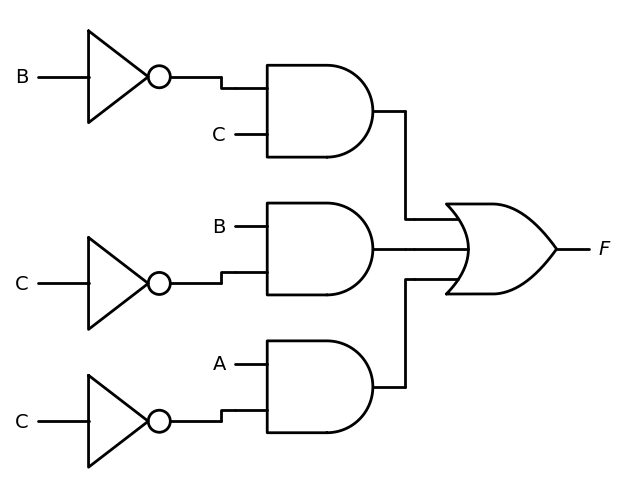

In [24]:
cover_F = solve(ones_F, 3, "ABC", "F", title="Exercise 6")

In [25]:
# Two equally minimal solutions exist. Both can also be written with an XOR gate:
F_xor_1 = lambda a, b, c: OR(XOR(b, c), AND(a, NOT(b)))
F_xor_2 = lambda a, b, c: OR(XOR(b, c), AND(a, NOT(c)))
F_ref   = lambda a, b, c: table_F[a * 4 + b * 2 + c]
assert equivalent(F_xor_1, F_ref, 3) and equivalent(F_xor_2, F_ref, 3)
print("F = (B xor C) + A.not(B)  =  (B xor C) + A.not(C)   both verified")

F = (B xor C) + A.not(B)  =  (B xor C) + A.not(C)   both verified


## Summary

| Step | Tool in this notebook |
|---|---|
| Specification → truth table | `truth_table`, `matches` |
| Prove an identity | `equivalent` (exhaustive) |
| Canonical SOP | `canonical_sop` |
| Visual simplification | `plot_kmap` |
| Automatic check | `prime_implicants`, `minimal_covers` |
| Whole pipeline + circuit | `solve`, `draw_circuit` |

**Next:** `04_combinational_and_sequential_circuits.ipynb` – adders, decoders, comparators and flip-flops.